In [61]:
# CRISPR CAR-T Project — PCA & Functional Module Summary

# This notebook summarizes the main analyses for the CRISPR CAR-T project:

# 1. Load processed expression & metadata.
# 2. Run PCA on selected features.
# 3. Interpret PCs using effector and regulatory gene modules.
# 4. Assign cells to quadrants based on PC5/PC6 (effector vs regulatory axes).
# 5. Visualize key results and save figures + tables.

# Notebook goal: provide a clean, reproducible narrative from raw matrices → interpretable biology.

In [62]:
from analysis_utils.config_utils import (
    PROJECT_ROOT,
    PROCESSED_DIR,
    RESULTS_DIR,
    PCA_RESULTS_DIR,
)


In [63]:
from pathlib import Path
import sys

# Absolute path to your project root
PROJECT_ROOT = Path("/Users/acastano/Desktop/crispr_carT_AI_analysis")

# Make sure Python can see analysis_utils
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT on sys.path:", PROJECT_ROOT in map(Path, sys.path))


PROJECT_ROOT on sys.path: True


In [64]:
from pathlib import Path
import sys
import pandas as pd

from analysis_utils.config_utils import (
    PROJECT_ROOT,
    PROCESSED_DIR,
    RESULTS_DIR,
    PCA_RESULTS_DIR,
)

from analysis_utils.pca_utils import run_pca, save_pca_results, plot_pca_scatter


# Just to sanity-check:
PROJECT_ROOT, PROCESSED_DIR, PCA_RESULTS_DIR


(PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis'),
 PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/data/processed'),
 PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/pca'))

In [65]:
import analysis_utils
analysis_utils.__file__


'/Users/acastano/Desktop/crispr_carT_AI_analysis/analysis_utils/__init__.py'

In [66]:
expr_logcpm = pd.read_parquet(PROCESSED_DIR / "expr_logcpm.parquet")

In [67]:
mapping_df = pd.read_csv(PROCESSED_DIR / "ensg_to_symbol.csv")
ensg_to_symbol = dict(zip(mapping_df["ensembl"], mapping_df["symbol"]))


In [68]:
from analysis_utils.module_pipeline import map_expression_to_symbols
expr_symbol = map_expression_to_symbols(expr_logcpm, ensg_to_symbol)



In [69]:
meta = pd.read_csv(PROCESSED_DIR / "metadata_samples.csv", index_col=0)
expr_symbol.columns == meta.index

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

In [70]:
from analysis_utils.module_pipeline import map_expression_to_symbols

# Build mapping dict from the CSV
ensg_to_symbol = dict(zip(mapping_df["ensembl"], mapping_df["symbol"]))

# Apply ENSG → SYMBOL mapping
expr_symbol = map_expression_to_symbols(expr_logcpm, ensg_to_symbol)

expr_symbol.head()

,CART0077_RNAseq_NgsRun1_001,CART0077_RNAseq_NgsRun1_002,CART0077_RNAseq_NgsRun1_003,CART0077_RNAseq_NgsRun1_004,CART0077_RNAseq_NgsRun1_005,CART0077_RNAseq_NgsRun1_006,CART0077_RNAseq_NgsRun1_007,CART0077_RNAseq_NgsRun1_008,CART0077_RNAseq_NgsRun1_009,CART0077_RNAseq_NgsRun1_010,...,CART0077_RNAseq_NgsRun1_051,CART0077_RNAseq_NgsRun1_052,CART0077_RNAseq_NgsRun1_053,CART0077_RNAseq_NgsRun1_054,CART0077_RNAseq_NgsRun1_055,CART0077_RNAseq_NgsRun1_056,CART0077_RNAseq_NgsRun1_057,CART0077_RNAseq_NgsRun1_058,CART0077_RNAseq_NgsRun1_059,CART0077_RNAseq_NgsRun1_060
gene_symbol,,,,,,,,,,,,,,,,,,,,,
A1BG,0.063729,0.233937,0.230089,0.027546,0.140237,0.083679,0.119019,0.104961,0.031403,0.064387,...,0.291773,0.210028,0.263343,0.145059,0.500513,0.336267,0.141521,0.201050,0.156030,0.231409
A1BG-AS1,2.294187,2.301634,2.025882,2.125033,1.916338,2.028702,2.328075,2.420824,2.225959,2.401735,...,2.505373,2.543098,2.552231,2.475571,2.780749,2.781865,2.744467,2.767573,2.636810,2.676867
A1CF,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.061682,0.000000,0.000000
A2M,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.042139,0.000000,0.000000,0.000000,0.000000,0.000000,0.033215,0.000000
A2M-AS1,0.000000,0.000000,0.000000,0.000000,0.203609,0.135813,0.000000,0.071183,0.000000,0.000000,...,0.156490,0.000000,0.158845,0.210391,0.000000,0.000000,0.000000,0.031317,0.363976,0.352843


In [71]:
scores_df, loadings_df, explained_df, pca = run_pca(
    expr_symbol,
    n_components=20,
    center=True,
    scale=False,
    random_state=0,
)



scores_df.head(), loadings_df.shape, explained_df


(                                   PC1        PC2        PC3       PC4  \
 CART0077_RNAseq_NgsRun1_001 -36.608980 -31.024521 -11.759580 -2.347379   
 CART0077_RNAseq_NgsRun1_002 -38.726879 -31.195909 -10.533219 -3.004145   
 CART0077_RNAseq_NgsRun1_003 -30.944237 -29.247542 -16.600241 -0.461992   
 CART0077_RNAseq_NgsRun1_004 -39.028631 -31.262182 -11.640999 -3.257525   
 CART0077_RNAseq_NgsRun1_005 -39.389334 -32.215399  -9.875385 -7.902223   
 
                                    PC5        PC6        PC7       PC8  \
 CART0077_RNAseq_NgsRun1_001 -14.999687  -9.153062  -2.259850  7.547892   
 CART0077_RNAseq_NgsRun1_002 -15.452616  -7.875105  -2.334574  9.496644   
 CART0077_RNAseq_NgsRun1_003 -11.289210  -9.726801  11.787962 -3.684116   
 CART0077_RNAseq_NgsRun1_004 -14.183817  -6.049385  12.044974  2.646580   
 CART0077_RNAseq_NgsRun1_005 -21.834669  12.375365  -1.941011 -1.475373   
 
                                    PC9      PC10      PC11      PC12  \
 CART0077_RNAseq_NgsRun

In [72]:
save_pca_results(
    scores_df=scores_df,
    loadings_df=loadings_df,
    explained_df=explained_df,
    out_dir=PCA_RESULTS_DIR,
)


In [74]:
# Identify any existing PC columns in meta
pc_cols_in_meta = [c for c in meta.columns if c.startswith("PC")]

# Drop them (if none exist, errors="ignore" keeps it safe)
meta_clean = meta.drop(columns=pc_cols_in_meta, errors="ignore")

# Now join the fresh scores
meta_with_pcs = meta_clean.join(scores_df, how="left")

meta_with_pcs.head()




,GSM,title,cell_type,hours,guide,donor,PC1,PC2,PC3,PC4,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
sample_id,,,,,,,,,,,,,,,,,,,,,
CART0077_RNAseq_NgsRun1_001,"""GSM8252546""","""CD4, 0h, SafeHarbor, CART0077_D1""",CD4,0,SafeHarbor,CART0077_D1,-36.608980,-31.024521,-11.759580,-2.347379,...,-1.783244,-8.906770,3.175437,-1.220633,-3.416751,-0.973683,-2.629760,0.304593,0.669344,3.532576
CART0077_RNAseq_NgsRun1_002,"""GSM8252547""","""CD4, 0h, RHOG, CART0077_D1""",CD4,0,RHOG,CART0077_D1,-38.726879,-31.195909,-10.533219,-3.004145,...,-1.787556,-5.944062,1.334272,-0.640531,-2.797774,-2.614060,-2.349428,-0.284004,-1.433859,1.229688
CART0077_RNAseq_NgsRun1_003,"""GSM8252548""","""CD4, 0h, SafeHarbor, CART0077_D2""",CD4,0,SafeHarbor,CART0077_D2,-30.944237,-29.247542,-16.600241,-0.461992,...,0.512577,-6.636773,1.566247,-1.428228,6.346484,2.799048,-2.150189,2.857538,2.966854,-0.384266
CART0077_RNAseq_NgsRun1_004,"""GSM8252549""","""CD4, 0h, RHOG, CART0077_D2""",CD4,0,RHOG,CART0077_D2,-39.028631,-31.262182,-11.640999,-3.257525,...,-1.192829,-1.065661,-0.963558,1.489930,4.656184,-0.559286,0.721092,2.426362,-3.893079,-3.277492
CART0077_RNAseq_NgsRun1_005,"""GSM8252550""","""CD4, 0h, SafeHarbor, CART0077_D3""",CD4,0,SafeHarbor,CART0077_D3,-39.389334,-32.215399,-9.875385,-7.902223,...,-2.504313,4.270357,-1.501922,-1.624859,1.213262,-0.304563,2.625938,-0.861574,1.818906,-0.198254


In [79]:
meta_with_pcs = meta.join(scores_df, how="left")

meta_out_dir = RESULTS_DIR / "modules"
meta_out_dir.mkdir(parents=True, exist_ok=True)

meta_with_pcs.to_parquet(meta_out_dir / "metadata_with_pcs.parquet")
meta_with_pcs.to_csv(meta_out_dir / "metadata_with_pcs.csv")


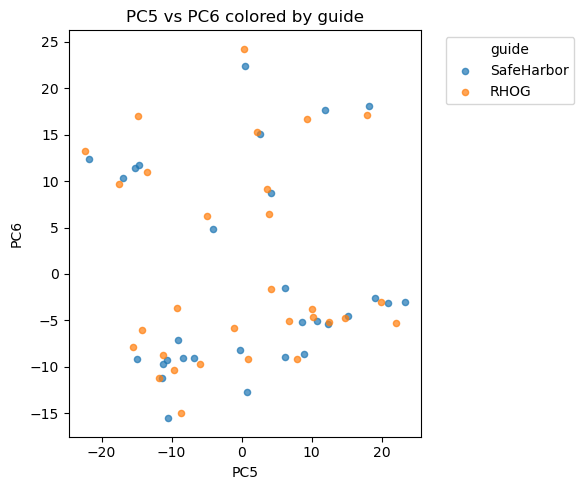

In [76]:
fig_path = PCA_RESULTS_DIR / "fig_pca_PC5_PC6_by_guide.png"

fig, ax = plot_pca_scatter(
    scores_df=scores_df,
    meta=meta,
    pc_x="PC5",
    pc_y="PC6",
    color_by="guide",
    out_path=fig_path,
)


(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'PC5 vs PC6 colored by hours'}, xlabel='PC5', ylabel='PC6'>)

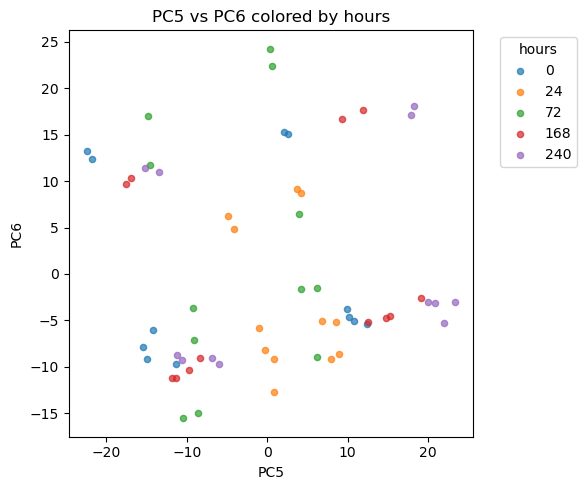

In [77]:
fig_path2 = PCA_RESULTS_DIR / "fig_pca_PC5_PC6_by_hours.png"

plot_pca_scatter(
    scores_df=scores_df,
    meta=meta,
    pc_x="PC5",
    pc_y="PC6",
    color_by="hours",
    out_path=fig_path2,
)


In [78]:
meta.index.equals(scores_df.index)


True

In [85]:
scores_df, loadings_df, explained_df, pca = run_pca(
    expr_symbol,
    n_components=20,   # or whatever you want
    center=True,
    scale=False,
    random_state=0,
)

scores_df.head()




,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
CART0077_RNAseq_NgsRun1_001,-36.608980,-31.024521,-11.759580,-2.347379,-14.999687,-9.153062,-2.259850,7.547892,-5.554881,2.444653,-1.783244,-8.906770,3.175437,-1.220633,-3.416751,-0.973683,-2.629760,0.304593,0.669344,3.532576
CART0077_RNAseq_NgsRun1_002,-38.726879,-31.195909,-10.533219,-3.004145,-15.452616,-7.875105,-2.334574,9.496644,-6.437116,3.754927,-1.787556,-5.944062,1.334272,-0.640531,-2.797774,-2.614060,-2.349428,-0.284004,-1.433859,1.229688
CART0077_RNAseq_NgsRun1_003,-30.944237,-29.247542,-16.600241,-0.461992,-11.289210,-9.726801,11.787962,-3.684116,-3.660495,-2.790931,0.512577,-6.636773,1.566247,-1.428228,6.346484,2.799048,-2.150189,2.857538,2.966854,-0.384266
CART0077_RNAseq_NgsRun1_004,-39.028631,-31.262182,-11.640999,-3.257525,-14.183817,-6.049385,12.044974,2.646580,-7.590086,2.380308,-1.192829,-1.065661,-0.963558,1.489930,4.656184,-0.559286,0.721092,2.426362,-3.893079,-3.277492
CART0077_RNAseq_NgsRun1_005,-39.389334,-32.215399,-9.875385,-7.902223,-21.834669,12.375365,-1.941011,-1.475373,-10.674327,2.484162,-2.504313,4.270357,-1.501922,-1.624859,1.213262,-0.304563,2.625938,-0.861574,1.818906,-0.198254
